# Import Libraries

In [28]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
import time
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Conv1D, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

# Step 1: Data Collection & Preprocessing

In [29]:
SYMBOL = 'IBM'
SEED = 90

print(f"Fetching 5 years of unlimited data for {SYMBOL} from Yahoo Finance...")
# yfinance downloads the full dataset instantly, no premium required
df = yf.download(SYMBOL, period='5y')

# Clean up the columns (yfinance sometimes returns a MultiIndex)
if isinstance(df.columns, pd.MultiIndex):
    df_close = df['Close'][[SYMBOL]].rename(columns={SYMBOL: 'Close'})
else:
    df_close = df[['Close']]

# Scale the data for the neural network
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_close.values)

# Create 60-day sequences
sequence_length = 60
X, y = [], []
for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

# Split into 80% Training and 20% Testing
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Data successfully loaded! Total sequences ready for training: {len(X)}")

# Dictionary to store our new time and epoch metrics
training_stats = {}

Fetching 5 years of unlimited data for IBM from Yahoo Finance...


[*********************100%***********************]  1 of 1 completed

Data successfully loaded! Total sequences ready for training: 1196


# STEP 2: MODEL BUILDING & TRAINING

In [30]:
# --- LSTM MODEL ---
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

print("\n--- Training LSTM Model ---")
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')

start_time = time.time() # <-- Start Timer
history_lstm = lstm_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)
lstm_time = time.time() - start_time # <-- End Timer
# Extract exact number of epochs run before early stopping
lstm_epochs = len(history_lstm.history['loss']) 
training_stats['LSTM'] = {'time': lstm_time, 'epochs': lstm_epochs}


--- Training LSTM Model ---
Epoch 1/100


c:\A1 Bukhari\1 UM\Y4 S2\ML\Assignment-FSA1\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0089 - val_loss: 0.0226
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0014 - val_loss: 0.0046
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 7.3142e-04 - val_loss: 0.0023
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 7.4564e-04 - val_loss: 0.0019
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 6.5975e-04 - val_loss: 0.0019
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 7.3326e-04 - val_loss: 0.0019
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 6.2778e-04 - val_loss: 0.0021
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 6.7406e-04 - val_loss: 0.0028
Epoch 9/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 6.7819e-04 - val_loss: 0.0015
Epoch 10/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 5.0392e-04 - val_loss: 0.0015
Epoch 11/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 6.1347e-04 - val_loss: 0.0018
Epoch 12/100
24/24 ━━━━━━━━━

In [31]:
# --- GRU MODEL ---
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

print("\n--- Training GRU Model ---")
gru_model = Sequential([
    GRU(64, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    GRU(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])
gru_model.compile(optimizer='adam', loss='mse')

start_time = time.time() # <-- Start Timer
history_gru = gru_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)
gru_time = time.time() - start_time # <-- End Timer
gru_epochs = len(history_gru.history['loss'])
training_stats['GRU'] = {'time': gru_time, 'epochs': gru_epochs}


--- Training GRU Model ---
Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0101 - val_loss: 0.0260
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 5.0401e-04 - val_loss: 0.0010
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 5.3477e-04 - val_loss: 0.0016
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 4.8853e-04 - val_loss: 9.6749e-04
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 5.6095e-04 - val_loss: 8.3553e-04
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 4.6971e-04 - val_loss: 0.0019
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 5.2881e-04 - val_loss: 0.0014
Epoch 9/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 4.9993e-04 - val_loss: 0.0010
Epoch 10/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 3.5029e-04 - val_loss: 7.8313e-04
Epoch 11/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 4.3577

In [32]:
# --- BIDIRECTIONAL GRU MODEL ---
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

print("\n--- Training Bidirectional GRU Model ---")
bigru_model = Sequential([
    # Wrap the GRU layer in Bidirectional()
    Bidirectional(GRU(64, return_sequences=False), input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

bigru_model.compile(optimizer='adam', loss='mse')

start_time = time.time()
history_bigru = bigru_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)
bigru_time = time.time() - start_time
bigru_epochs = len(history_bigru.history['loss'])
training_stats['BiGRU'] = {'time': bigru_time, 'epochs': bigru_epochs}


--- Training Bidirectional GRU Model ---
Epoch 1/100


c:\A1 Bukhari\1 UM\Y4 S2\ML\Assignment-FSA1\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.0117 - val_loss: 0.0425
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0023 - val_loss: 0.0024
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0010 - val_loss: 0.0017
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 7.7264e-04 - val_loss: 0.0015
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 6.0336e-04 - val_loss: 0.0010
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 5.7216e-04 - val_loss: 0.0010
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 4.6132e-04 - val_loss: 0.0010
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 4.0498e-04 - val_loss: 7.5764e-04
Epoch 9/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 3.4905e-04 - val_loss: 7.9917e-04
Epoch 10/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 3.3438e-04 - val_loss: 6.9560e-04
Epoch 11/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 3.0636e-04 - val_loss: 7.2268e-04
Epoch 12/100
24/

In [33]:
# --- FIXED CNN-GRU Model ---
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

print("\n--- Training CNN-GRU Model ---")
cnn_gru_model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same', input_shape=(X_train.shape[1], 1)),   
    GRU(64, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

cnn_gru_model.compile(optimizer='adam', loss='mse')

start_time = time.time() # <-- Start Timer
history_cnn_gru = cnn_gru_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32, 
    callbacks=[early_stop], 
    verbose=1
)
cnn_gru_time = time.time() - start_time # <-- End Timer
cnn_gru_epochs = len(history_cnn_gru.history['loss'])
training_stats['CNN-GRU'] = {'time': cnn_gru_time, 'epochs': cnn_gru_epochs}


--- Training CNN-GRU Model ---
Epoch 1/100


c:\A1 Bukhari\1 UM\Y4 S2\ML\Assignment-FSA1\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0066 - val_loss: 0.0061
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 7.9940e-04 - val_loss: 7.0086e-04
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 4.5153e-04 - val_loss: 6.7669e-04
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 3.8110e-04 - val_loss: 7.4976e-04
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 3.4390e-04 - val_loss: 6.6478e-04
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 3.2704e-04 - val_loss: 7.2000e-04
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 3.0638e-04 - val_loss: 6.2639e-04
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 3.0581e-04 - val_loss: 7.9618e-04
Epoch 9/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 3.3360e-04 - val_loss: 6.0655e-04
Epoch 10/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 3.0298e-04 - val_loss: 7.4047e-04
Epoch 11/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 2.5886e-04 - val_l

# STEP 3: EVALUATION & SCALING BACK

In [34]:
lstm_pred = lstm_model.predict(X_test, verbose=0)
gru_pred = gru_model.predict(X_test, verbose=0)
bigru_pred = bigru_model.predict(X_test, verbose=0)
cnn_gru_pred = cnn_gru_model.predict(X_test, verbose=0)

# Reverse the 1D scaling directly
y_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
lstm_pred_actual = scaler.inverse_transform(lstm_pred)
gru_pred_actual = scaler.inverse_transform(gru_pred)
bigru_pred_actual = scaler.inverse_transform(bigru_pred)
cnn_gru_pred_actual = scaler.inverse_transform(cnn_gru_pred)

def evaluate(y_true, predictions_dict, stats_dict):
    results = []
    
    for model_name, y_pred in predictions_dict.items():
        mae = mean_absolute_error(y_true, y_pred)
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_true, y_pred)
        stats = stats_dict[model_name]

        # Append dictionary of results
        results.append({
            'Model': model_name,
            'Epochs': stats['epochs'],
            'Training Time (s)': round(stats['time'], 2),
            'Time/Epoch (s)': round(stats['time'] / stats['epochs'], 2),
            'MAE': round(mae, 2),
            'MSE': round(mse, 2),
            'RMSE': round(rmse, 2),
            'R²': round(r2, 4)
        })

    # Convert list of dictionaries to a Pandas DataFrame
    df = pd.DataFrame(results)
    return df

predictions = {
    "GRU": gru_pred_actual,
    "LSTM": lstm_pred_actual,
    "BiGRU": bigru_pred_actual,
    "CNN-GRU": cnn_gru_pred_actual
}

results_df = evaluate(y_actual, predictions, training_stats)

print("--- Performance Metrics Table ---")
print(results_df.to_string(index=False)) 

--- Performance Metrics Table ---
  Model  Epochs  Training Time (s)  Time/Epoch (s)  MAE    MSE  RMSE     R²
    GRU      64              73.36            1.15 6.09  81.94  9.05 0.8909
   LSTM      31              24.53            0.79 9.57 191.11 13.82 0.7455
  BiGRU     100              74.06            0.74 5.03  58.03  7.62 0.9227
CNN-GRU      60              36.01            0.60 4.98  57.17  7.56 0.9239


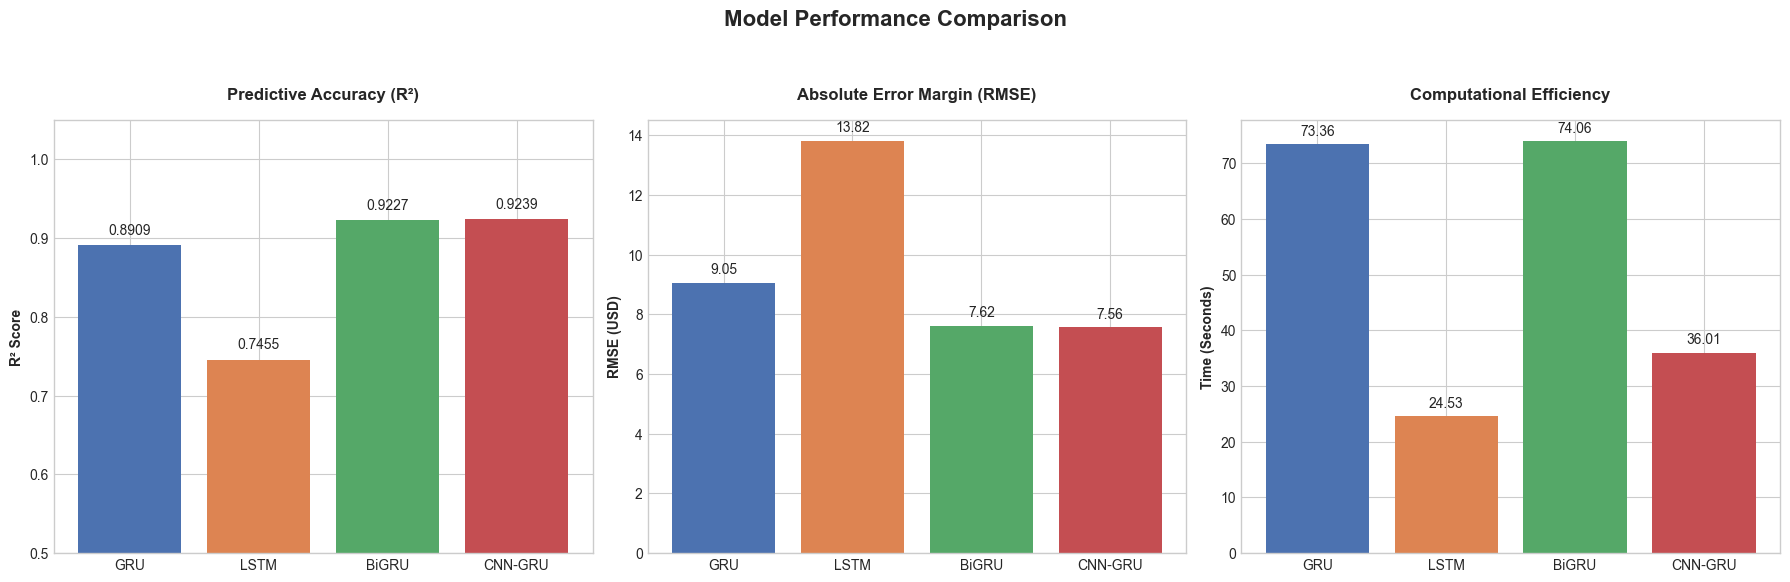

In [35]:
def plot_performance_charts(df):
    # Set up global plot style
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    
    models = df['Model']
    colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52'] # Distinct colors for each model

    # --- Plot 1: R² Score (Higher is Better) ---
    axes[0].bar(models, df['R²'], color=colors)
    axes[0].set_ylabel('R² Score', fontweight='bold')
    axes[0].set_title('Predictive Accuracy (R²)', fontweight='bold', pad=15)
    axes[0].set_ylim(0.5, 1.05) # Scaled to highlight differences
    
    # Add value labels on top of bars
    for i, v in enumerate(df['R²']):
        axes[0].text(i, v + 0.01, str(v), ha='center', va='bottom', fontsize=10)

    # --- Plot 2: RMSE (Lower is Better) ---
    axes[1].bar(models, df['RMSE'], color=colors)
    axes[1].set_ylabel('RMSE (USD)', fontweight='bold')
    axes[1].set_title('Absolute Error Margin (RMSE)', fontweight='bold', pad=15)
    
    for i, v in enumerate(df['RMSE']):
        axes[1].text(i, v + 0.2, str(v), ha='center', va='bottom', fontsize=10)

    # --- Plot 3: Training Time (Lower is Better) ---
    axes[2].bar(models, df['Training Time (s)'], color=colors)
    axes[2].set_ylabel('Time (Seconds)', fontweight='bold')
    axes[2].set_title('Computational Efficiency', fontweight='bold', pad=15)
    
    for i, v in enumerate(df['Training Time (s)']):
        axes[2].text(i, v + 1, str(v), ha='center', va='bottom', fontsize=10)

    # Final formatting
    plt.suptitle('Model Performance Comparison', fontsize=16, y=1.05, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Run the plot function
plot_performance_charts(results_df)

# STEP 4: VISUALIZATION

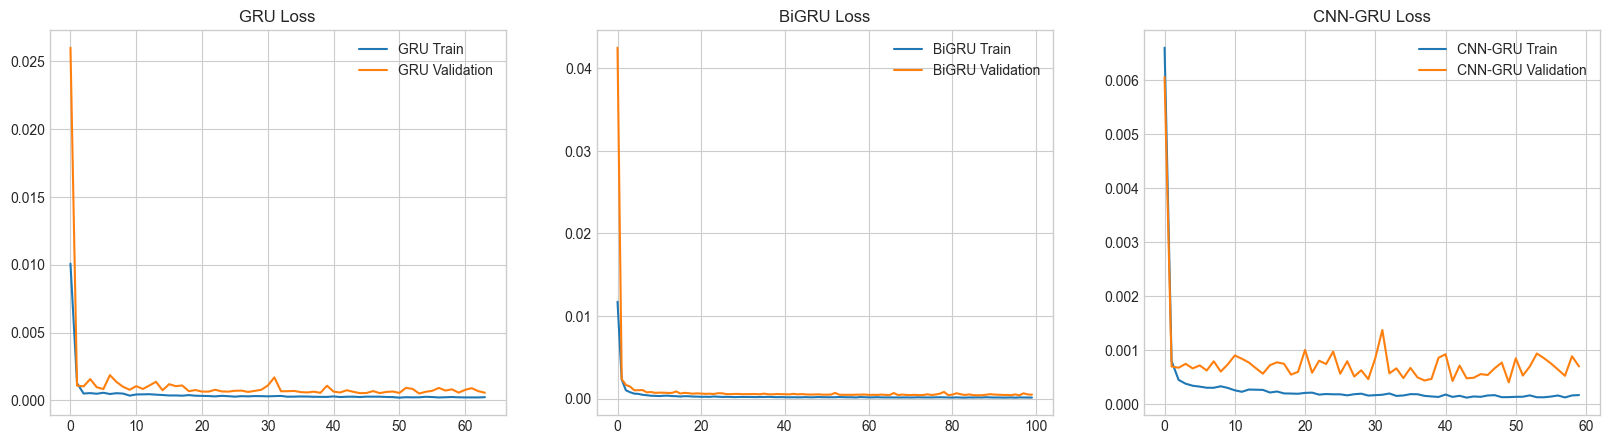

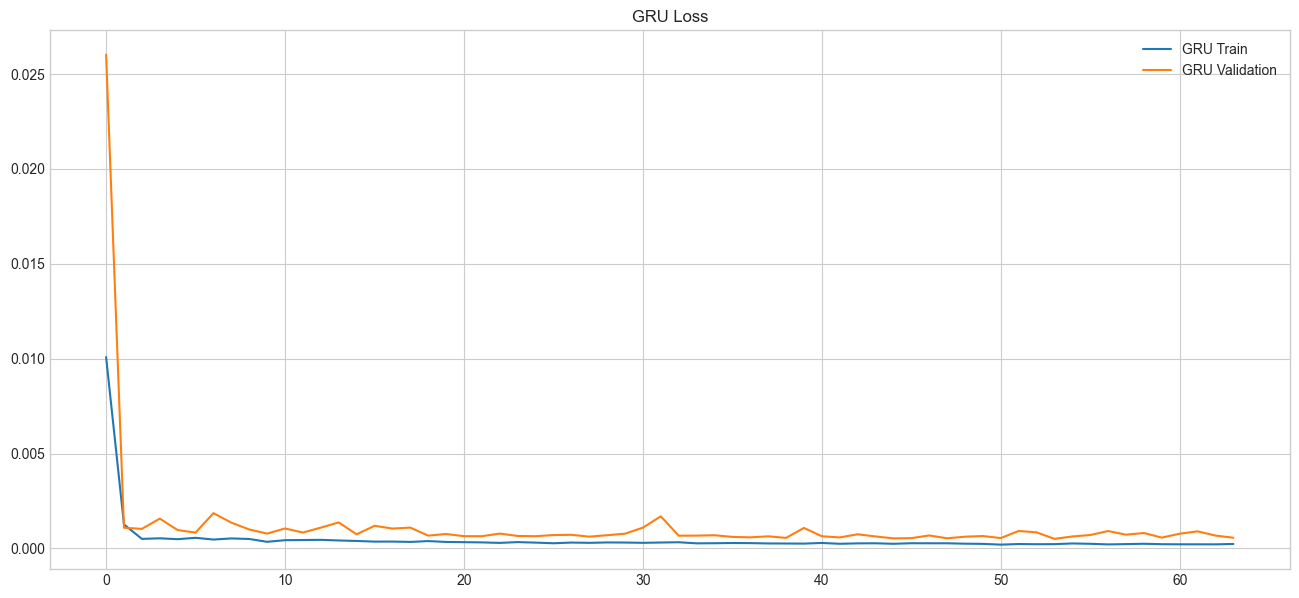

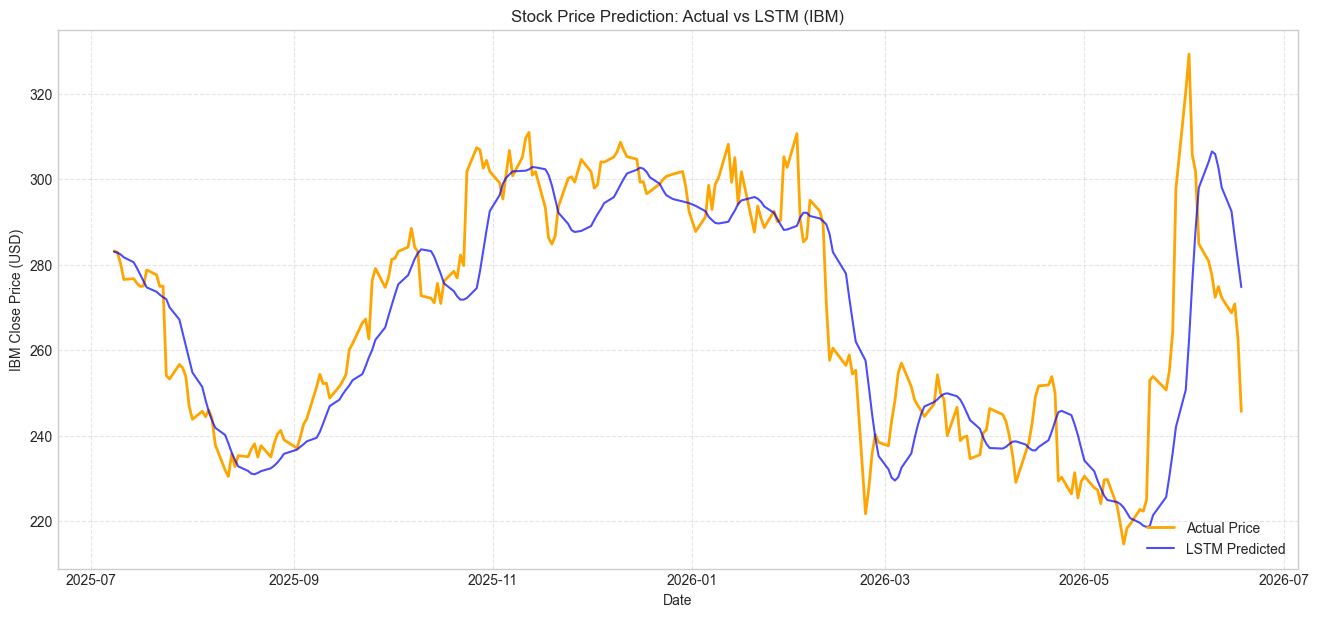

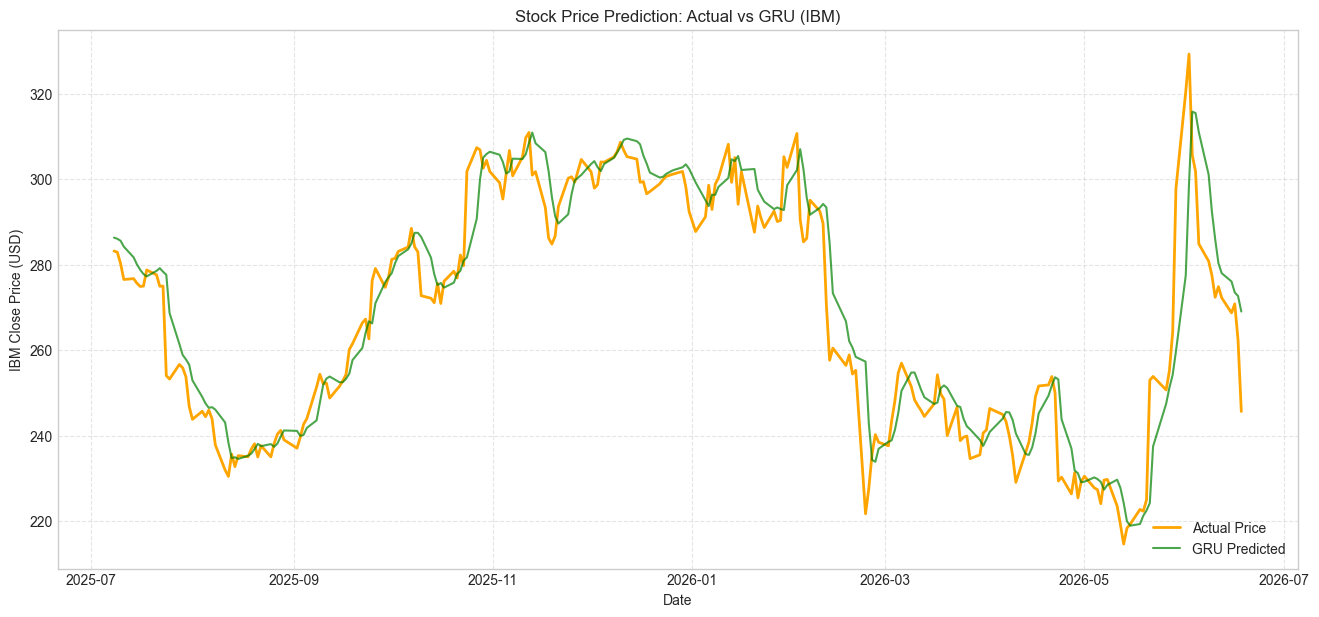

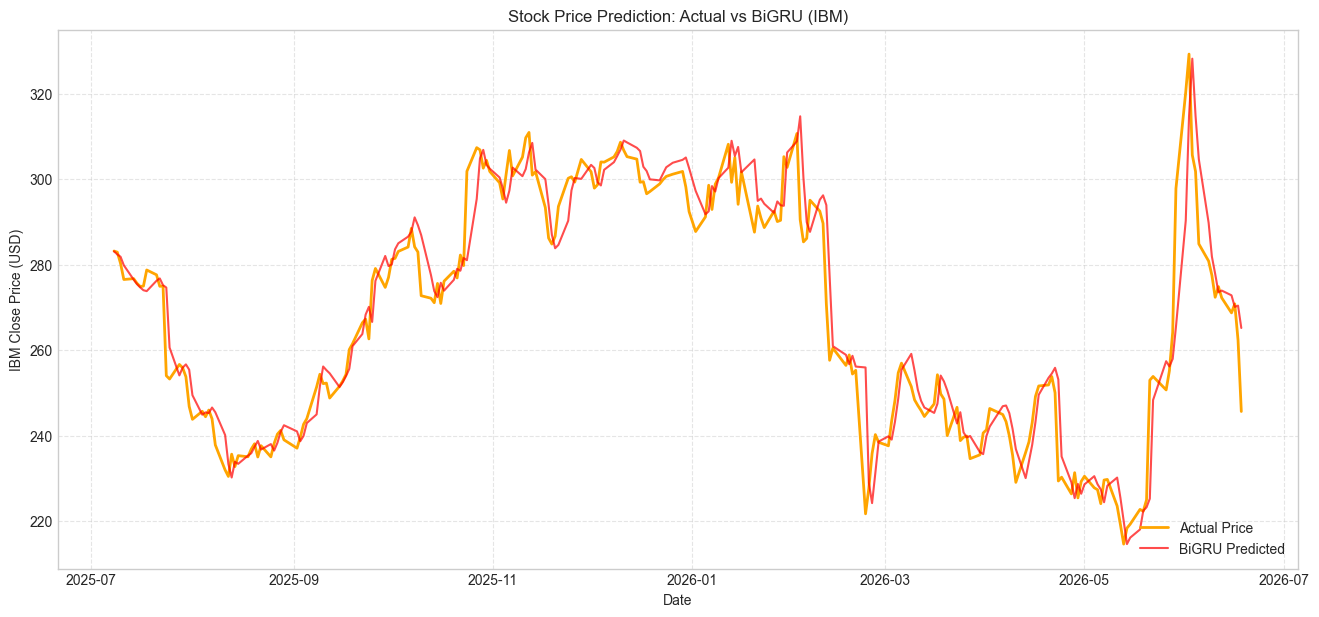

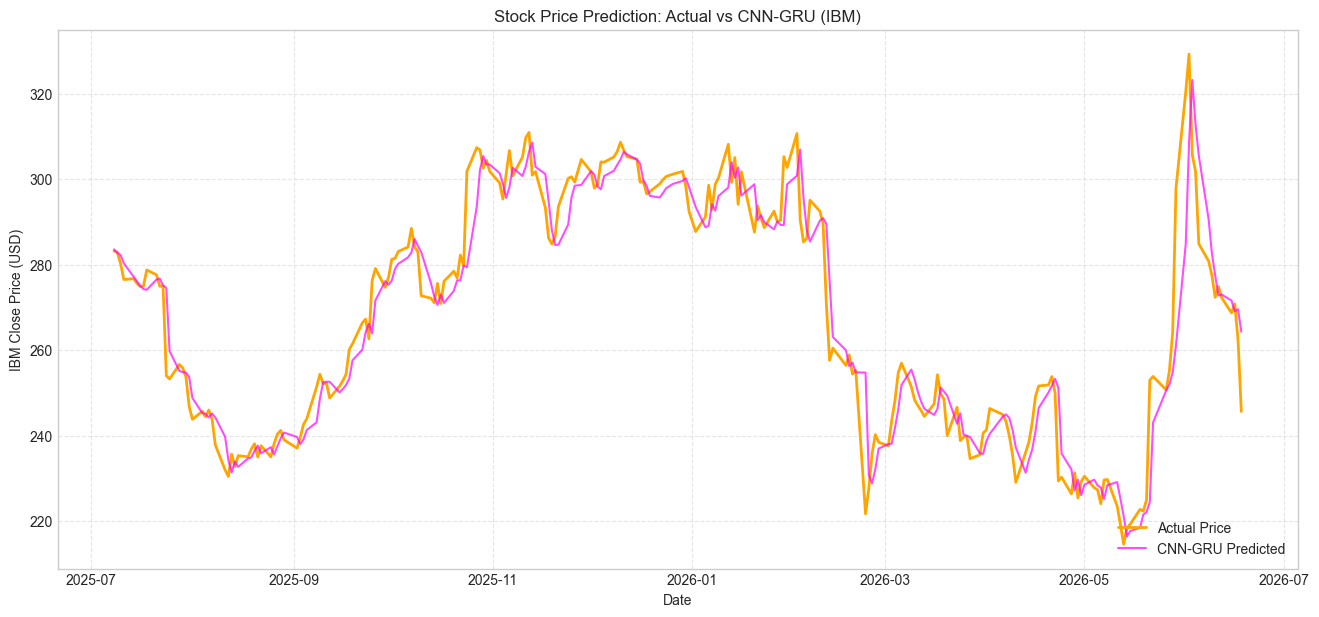

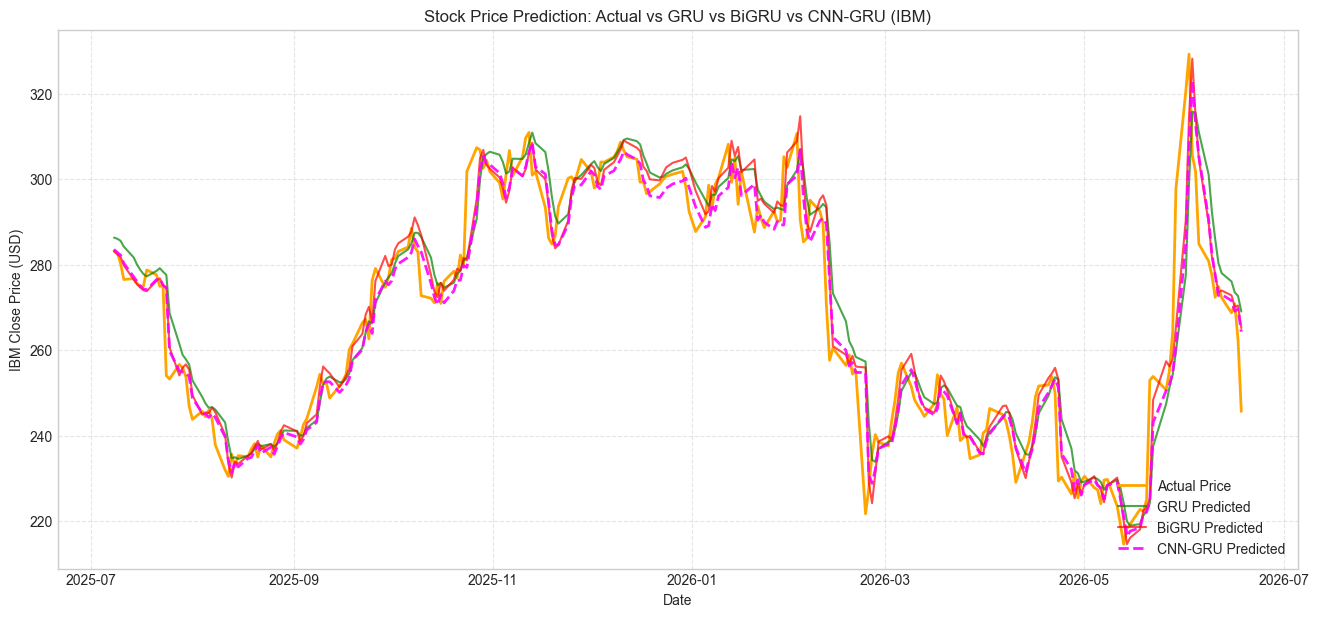

In [36]:
# 1. Loss Curves Comparison
fig, axes = plt.subplots(1,3 , figsize=(20, 5))
axes[0].plot(history_gru.history['loss'], label='GRU Train')
axes[0].plot(history_gru.history['val_loss'], label='GRU Validation')
axes[0].set_title('GRU Loss')
axes[0].legend()

axes[1].plot(history_bigru.history['loss'], label='BiGRU Train')
axes[1].plot(history_bigru.history['val_loss'], label='BiGRU Validation')
axes[1].set_title('BiGRU Loss')
axes[1].legend()

axes[2].plot(history_cnn_gru.history['loss'], label='CNN-GRU Train')
axes[2].plot(history_cnn_gru.history['val_loss'], label='CNN-GRU Validation')
axes[2].set_title('CNN-GRU Loss')
axes[2].legend()

plt.figure(figsize=(16, 7))
plt.plot(history_gru.history['loss'], label='GRU Train')
plt.plot(history_gru.history['val_loss'], label='GRU Validation')
plt.title('GRU Loss')
plt.legend()
plt.show()

# 2. Final Price Prediction Plot
# Extract actual dates for the x-axis
valid_dates = df_close.index[split+sequence_length:]

plt.figure(figsize=(16, 7))
plt.plot(valid_dates, y_actual, label='Actual Price', color='orange', linewidth=2)
plt.plot(valid_dates, lstm_pred_actual, label='LSTM Predicted', color='blue', alpha=0.7)

plt.title(f'Stock Price Prediction: Actual vs LSTM ({SYMBOL})')
plt.xlabel('Date')
plt.ylabel(f'{SYMBOL} Close Price (USD)')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()  


plt.figure(figsize=(16, 7))
plt.plot(valid_dates, y_actual, label='Actual Price', color='orange', linewidth=2)
plt.plot(valid_dates, gru_pred_actual, label='GRU Predicted', color='green', alpha=0.7)

plt.title(f'Stock Price Prediction: Actual vs GRU ({SYMBOL})')
plt.xlabel('Date')
plt.ylabel(f'{SYMBOL} Close Price (USD)')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

plt.figure(figsize=(16, 7))
plt.plot(valid_dates, y_actual, label='Actual Price', color='orange', linewidth=2)
plt.plot(valid_dates, bigru_pred_actual, label='BiGRU Predicted', color='red', alpha=0.7)

plt.title(f'Stock Price Prediction: Actual vs BiGRU ({SYMBOL})')
plt.xlabel('Date')
plt.ylabel(f'{SYMBOL} Close Price (USD)')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()  


plt.figure(figsize=(16, 7))
plt.plot(valid_dates, y_actual, label='Actual Price', color='orange', linewidth=2)
plt.plot(valid_dates, cnn_gru_pred_actual, label='CNN-GRU Predicted', color='magenta', alpha=0.7)

plt.title(f'Stock Price Prediction: Actual vs CNN-GRU ({SYMBOL})')
plt.xlabel('Date')
plt.ylabel(f'{SYMBOL} Close Price (USD)')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


plt.figure(figsize=(16, 7))
plt.plot(valid_dates, y_actual, label='Actual Price', color='orange', linewidth=2)
plt.plot(valid_dates, gru_pred_actual, label='GRU Predicted', color='green', alpha=0.7)
plt.plot(valid_dates, bigru_pred_actual, label='BiGRU Predicted', color='red', alpha=0.7)
plt.plot(valid_dates, cnn_gru_pred_actual, label='CNN-GRU Predicted', color='magenta', alpha=0.9, linewidth=2, linestyle='--')

plt.title(f'Stock Price Prediction: Actual vs GRU vs BiGRU vs CNN-GRU ({SYMBOL})')
plt.xlabel('Date')
plt.ylabel(f'{SYMBOL} Close Price (USD)')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()